---
# Notebook 4 — Inference & Prediction Sandbox
### Pakistan Export Demand Forecasting System | Final Year Project

---

## What This Notebook Does
This notebook **does not train anything**. It loads the saved XGBoost champion model and uses it to generate predictions for future months.

This code is the exact blueprint for the FastAPI backend — every function here maps directly to an API endpoint.

## Workflow
```
Load .pkl artifact
      ↓
Look up lag values from master dataset
      ↓
Build feature row (same format as training)
      ↓
model.predict() → Export Value (USD)
```

## Sections
| # | Section |
|---|----------|
| 1 | Load Champion Model |
| 2 | Inspect Artifact |
| 3 | Load Master Dataset (lag lookup) |
| 4 | Prediction Helper Function |
| 5 | Single Commodity Prediction |
| 6 | Forecast All 10 Commodities |
| 7 | Scenario Simulator |
| 8 | Summary |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

print('Libraries loaded.')

Libraries loaded.


---
## Section 1 — Load Champion Model

The `.pkl` file contains everything needed to make predictions:
- The trained XGBoost model
- The exact list of features (in training order)
- The HS_Code category list (must match training)
- Commodity labels and training metadata

In [2]:
ARTIFACT_PATH = Path('..') / 'Models' / 'xgboost_champion.pkl'

artifact = joblib.load(ARTIFACT_PATH)

print(f'Model loaded from : {ARTIFACT_PATH.resolve()}')
print(f'Artifact keys     : {list(artifact.keys())}')

Model loaded from : C:\Users\Talha Abbasi\Desktop\PECDF\Models\xgboost_champion.pkl
Artifact keys     : ['model', 'feature_cols', 'hs_categories', 'hs_labels', 'train_cutoff', 'test_mape', 'test_r2']


---
## Section 2 — Inspect Artifact

Unpack all components from the artifact and confirm everything looks correct before making predictions.

In [3]:
# Unpack all artifact components
model         = artifact['model']
FEATURE_COLS  = artifact['feature_cols']
hs_categories = artifact['hs_categories']
HS_LABELS     = artifact['hs_labels']
train_cutoff  = artifact['train_cutoff']
test_mape     = artifact['test_mape']
test_r2       = artifact['test_r2']

print(f'Model type       : {type(model).__name__}')
print(f'Features ({len(FEATURE_COLS)})    : {FEATURE_COLS}')
print(f'Commodities ({len(hs_categories)}) : {hs_categories}')
print(f'Trained up to    : {train_cutoff}')
print(f'Test MAPE        : {test_mape}%')
print(f'Test R²          : {test_r2}')

Model type       : XGBRegressor
Features (13)    : ['HS_Code', 'USD_PKR_Close', 'Brent_Oil_Avg', 'US_Consumer_Confidence', 'Year', 'Month', 'Month_Sin', 'Month_Cos', 'Lag_1M', 'Lag_3M', 'Lag_6M', 'Rolling_3M_Avg', 'Rolling_6M_Avg']
Commodities (10) : ['1006', '1207', '2523', '5205', '6110', '6203', '6302', '7403', '9018', '9506']
Trained up to    : 202312
Test MAPE        : 20.41%
Test R²          : 0.9482


---
## Section 3 — Load Master Dataset

The model needs **lag features** (last month's export, 3 months ago, 6 months ago) for every prediction.  
We load the master dataset and use it as a lookup table to fill those lag values automatically.  
This way the user only needs to supply the macro variables — the lags are extracted from history.

In [4]:
DATA_PATH = Path('..') / 'Data' / 'Master_FYP_Dataset.csv'
master_df = pd.read_csv(DATA_PATH, dtype={'HS_Code': str})

print(f'Master dataset loaded — {master_df.shape[0]} rows')
print(f'Date range : {master_df["Date_YYYYMM"].min()}  to  {master_df["Date_YYYYMM"].max()}')
print()
print('Lag values for Jan 2026 will be pulled from Dec / Oct / Jul 2025 actuals.')

Master dataset loaded — 1860 rows
Date range : 201007  to  202512

Lag values for Jan 2026 will be pulled from Dec / Oct / Jul 2025 actuals.


---
## Section 4 — Prediction Helper Function

This function is the core of the inference pipeline. Given a commodity, a target month, and macro inputs, it:
1. Computes cyclic month encoding (same formula as Notebook 1)
2. Looks up lag and rolling values from the master dataset
3. Assembles the feature row in the exact column order the model expects
4. Applies the same `HS_Code` category dtype used during training
5. Returns the model's prediction in USD

**This function is the FastAPI `/predict` endpoint in Python form.**

In [5]:
def make_prediction(hs_code, target_yyyymm, usd_pkr, brent_oil, us_conf, forecast_buffer=None):
    if forecast_buffer is None:
        forecast_buffer = {}

    target_dt = pd.to_datetime(str(target_yyyymm), format='%Y%m')
    year      = target_dt.year
    month     = target_dt.month

    # Cyclic month encoding — same formula as Notebook 1
    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)

    # Build a lookup series: Date_YYYYMM -> Export_Value_USD for this commodity
    comm_series = (
        master_df[master_df['HS_Code'] == str(hs_code)]
        .set_index('Date_YYYYMM')['Export_Value_USD']
    )

    def get_lag(months_back):
        lag_key = int((target_dt - pd.DateOffset(months=months_back)).strftime('%Y%m'))
        # Check forecast buffer first — contains predictions for months not yet in master_df
        if (str(hs_code), lag_key) in forecast_buffer:
            return forecast_buffer[(str(hs_code), lag_key)]
        return comm_series.get(lag_key, np.nan)

    lag1  = get_lag(1)
    lag3  = get_lag(3)
    lag6  = get_lag(6)
    roll3 = np.nanmean([get_lag(i) for i in range(1, 4)])
    roll6 = np.nanmean([get_lag(i) for i in range(1, 7)])

    # Build feature row — column order must match FEATURE_COLS exactly
    row = pd.DataFrame([{
        'HS_Code'               : str(hs_code),
        'USD_PKR_Close'         : usd_pkr,
        'Brent_Oil_Avg'         : brent_oil,
        'US_Consumer_Confidence': us_conf,
        'Year'                  : year,
        'Month'                 : month,
        'Month_Sin'             : month_sin,
        'Month_Cos'             : month_cos,
        'Lag_1M'                : lag1,
        'Lag_3M'                : lag3,
        'Lag_6M'                : lag6,
        'Rolling_3M_Avg'        : roll3,
        'Rolling_6M_Avg'        : roll6,
    }])[FEATURE_COLS]

    # Apply category dtype — must match training preprocessing exactly
    row['HS_Code'] = pd.Categorical(row['HS_Code'], categories=hs_categories)

    pred = model.predict(row)[0]
    return max(0.0, pred)   # export values cannot be negative


print('make_prediction() defined.')
print('Inputs : hs_code, target_yyyymm, usd_pkr, brent_oil, us_conf, forecast_buffer (optional)')
print('Output : predicted export value in USD')

make_prediction() defined.
Inputs : hs_code, target_yyyymm, usd_pkr, brent_oil, us_conf, forecast_buffer (optional)
Output : predicted export value in USD


---
## Section 5 — Single Commodity Prediction

Test the helper function with one commodity (Rice, HS 1006) for **January 2026**.  
Edit the macro inputs below to explore different economic conditions.

In [6]:
# --- Adjust these macro assumptions freely ---
USD_PKR   = 285.0   # USD/PKR exchange rate
BRENT_OIL = 78.0    # Brent crude (USD/barrel)
US_CONF   = 98.0    # US Consumer Confidence index

TARGET_HS    = '1006'   # Rice
TARGET_MONTH = 202601   # January 2026

pred_usd = make_prediction(TARGET_HS, TARGET_MONTH, USD_PKR, BRENT_OIL, US_CONF)

print('=' * 50)
print(f'  Commodity     : {HS_LABELS[TARGET_HS]} (HS {TARGET_HS})')
print(f'  Target month  : {TARGET_MONTH}')
print(f'  USD/PKR       : {USD_PKR}')
print(f'  Brent Oil     : ${BRENT_OIL}/bbl')
print(f'  US Confidence : {US_CONF}')
print('=' * 50)
print(f'  Predicted Exports : ${pred_usd:>18,.0f}')
print(f'                    : ${pred_usd/1e6:>14.2f} Million USD')
print('=' * 50)

  Commodity     : Rice (HS 1006)
  Target month  : 202601
  USD/PKR       : 285.0
  Brent Oil     : $78.0/bbl
  US Confidence : 98.0
  Predicted Exports : $       212,731,248
                    : $        212.73 Million USD


---
## Section 6 — Forecast All 10 Commodities

Run `make_prediction()` for every commodity for the same target month.  
This gives a complete export forecast for Pakistan in January 2026.

In [7]:
TARGET_MONTH = 202601

# --- Macro assumptions (edit to change the scenario) ---
USD_PKR   = 285.0
BRENT_OIL = 78.0
US_CONF   = 98.0

rows = []
for hs in hs_categories:
    pred = make_prediction(hs, TARGET_MONTH, USD_PKR, BRENT_OIL, US_CONF)
    rows.append({
        'HS_Code'      : hs,
        'Commodity'    : HS_LABELS[hs],
        'Predicted_USD': pred,
        'Predicted_M'  : round(pred / 1e6, 2)
    })

forecast_df = pd.DataFrame(rows).sort_values('Predicted_USD', ascending=False).reset_index(drop=True)

print(f'Forecast — All Commodities — {TARGET_MONTH}')
print(f'Macro assumptions: USD/PKR={USD_PKR}, Brent=${BRENT_OIL}/bbl, US_Conf={US_CONF}')
print('=' * 50)
print(forecast_df[['HS_Code', 'Commodity', 'Predicted_M']].to_string(index=False))
print('=' * 50)
print(f'Total predicted exports : ${forecast_df["Predicted_USD"].sum() / 1e6:.1f} Million USD')

Forecast — All Commodities — 202601
Macro assumptions: USD/PKR=285.0, Brent=$78.0/bbl, US_Conf=98.0
HS_Code      Commodity  Predicted_M
   6302     Bed Linens   292.489990
   6203     Mens Suits   233.940002
   1006           Rice   212.729996
   5205    Cotton Yarn    68.849998
   7403         Copper    65.970001
   6110    Winter Wear    52.880001
   9018 Medical Instr.    37.180000
   9506   Sports Goods    26.709999
   2523         Cement    23.379999
   1207      Oil Seeds    10.980000
Total predicted exports : $1025.1 Million USD


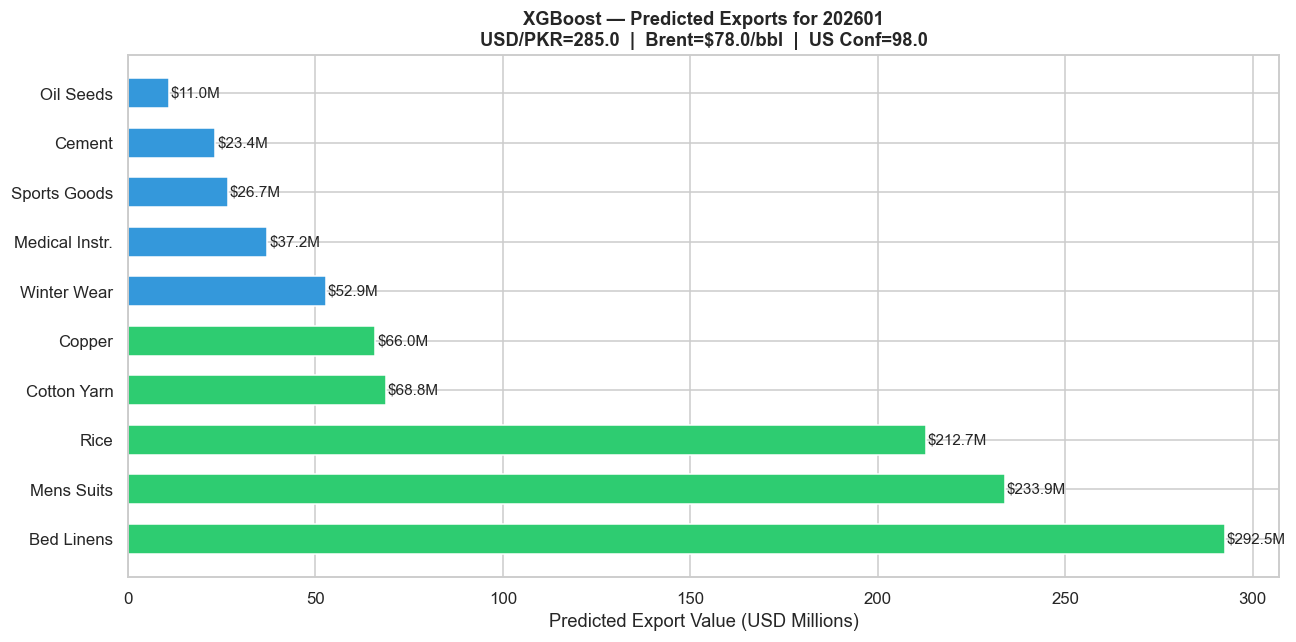

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

bar_colors = ['#2ecc71' if v >= forecast_df['Predicted_M'].median()
              else '#3498db' for v in forecast_df['Predicted_M'].values]

bars = ax.barh(forecast_df['Commodity'], forecast_df['Predicted_M'],
               color=bar_colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, forecast_df['Predicted_M'].values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'${val:.1f}M', va='center', fontsize=10)

ax.set_xlabel('Predicted Export Value (USD Millions)')
ax.set_title(
    f'XGBoost — Predicted Exports for {TARGET_MONTH}\n'
    f'USD/PKR={USD_PKR}  |  Brent=${BRENT_OIL}/bbl  |  US Conf={US_CONF}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
## Section 7 — 3-Month Rolling Forecast (Jan – Mar 2026)

Forecasting multiple months ahead requires **recursive/chained prediction**:

- **Jan 2026** → all lag values come from actual historical data (Dec 2025, Oct 2025, Jul 2025)
- **Feb 2026** → Lag_1M = Jan 2026 prediction (no actual yet), other lags from history
- **Mar 2026** → Lag_1M = Feb 2026 prediction, Lag_2M = Jan 2026 prediction, etc.

Each month's prediction feeds forward as the lag input for the next month.  
Uncertainty grows with each step — month 1 is most reliable, month 3 is least.

In [9]:
def forecast_n_months(start_yyyymm, n_months, usd_pkr, brent_oil, us_conf):
    # Generate the sequence of target months
    start_dt = pd.to_datetime(str(start_yyyymm), format='%Y%m')
    target_months = [
        int((start_dt + pd.DateOffset(months=i)).strftime('%Y%m'))
        for i in range(n_months)
    ]

    forecast_buffer = {}   # {(hs_code, yyyymm): predicted_value}
    all_results = []

    for month in target_months:
        for hs in hs_categories:
            pred = make_prediction(hs, month, usd_pkr, brent_oil, us_conf, forecast_buffer)
            # Store prediction so future months can use it as a lag value
            forecast_buffer[(str(hs), month)] = pred
            all_results.append({
                'Month'        : month,
                'HS_Code'      : hs,
                'Commodity'    : HS_LABELS[hs],
                'Predicted_USD': pred,
                'Predicted_M'  : round(pred / 1e6, 2)
            })

    return pd.DataFrame(all_results)


print('forecast_n_months() defined.')
print('Usage: forecast_n_months(start_yyyymm=202601, n_months=3, usd_pkr=285, brent_oil=78, us_conf=98)')

forecast_n_months() defined.
Usage: forecast_n_months(start_yyyymm=202601, n_months=3, usd_pkr=285, brent_oil=78, us_conf=98)


In [10]:
# --- Run 3-month forecast: Jan 2026, Feb 2026, Mar 2026 ---
USD_PKR   = 285.0
BRENT_OIL = 78.0
US_CONF   = 98.0

multi_df = forecast_n_months(
    start_yyyymm = 202601,
    n_months     = 3,
    usd_pkr      = USD_PKR,
    brent_oil    = BRENT_OIL,
    us_conf      = US_CONF
)

# Pivot to a wide table: rows = Commodity, columns = Month
pivot = multi_df.pivot(index='Commodity', columns='Month', values='Predicted_M')
pivot.columns = [str(c) for c in pivot.columns]
pivot['3M_Total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('3M_Total', ascending=False)

print(f'3-Month Recursive Forecast — Jan to Mar 2026')
print(f'Macro: USD/PKR={USD_PKR}, Brent=${BRENT_OIL}/bbl, US_Conf={US_CONF}')
print('=' * 60)
print(pivot.to_string())
print('=' * 60)
monthly_totals = multi_df.groupby('Month')['Predicted_USD'].sum() / 1e6
for month, total in monthly_totals.items():
    print(f'  {month}  Total : ${total:.1f}M USD')

3-Month Recursive Forecast — Jan to Mar 2026
Macro: USD/PKR=285.0, Brent=$78.0/bbl, US_Conf=98.0
                    202601      202602      202603    3M_Total
Commodity                                                     
Bed Linens      292.489990  290.070007  297.399994  879.959961
Mens Suits      233.940002  208.250000  217.410004  659.599976
Rice            212.729996  209.960007  194.380005  617.070007
Cotton Yarn      68.849998   79.669998   81.910004  230.429993
Copper           65.970001   59.279999   61.369999  186.619995
Winter Wear      52.880001   51.009998   46.299999  150.190002
Medical Instr.   37.180000   35.130001   36.020000  108.330002
Sports Goods     26.709999   26.900000   27.799999   81.410004
Cement           23.379999   18.840000   19.930000   62.150002
Oil Seeds        10.980000   12.240000   13.690000   36.910000
  202601  Total : $1025.1M USD
  202602  Total : $991.4M USD
  202603  Total : $996.2M USD


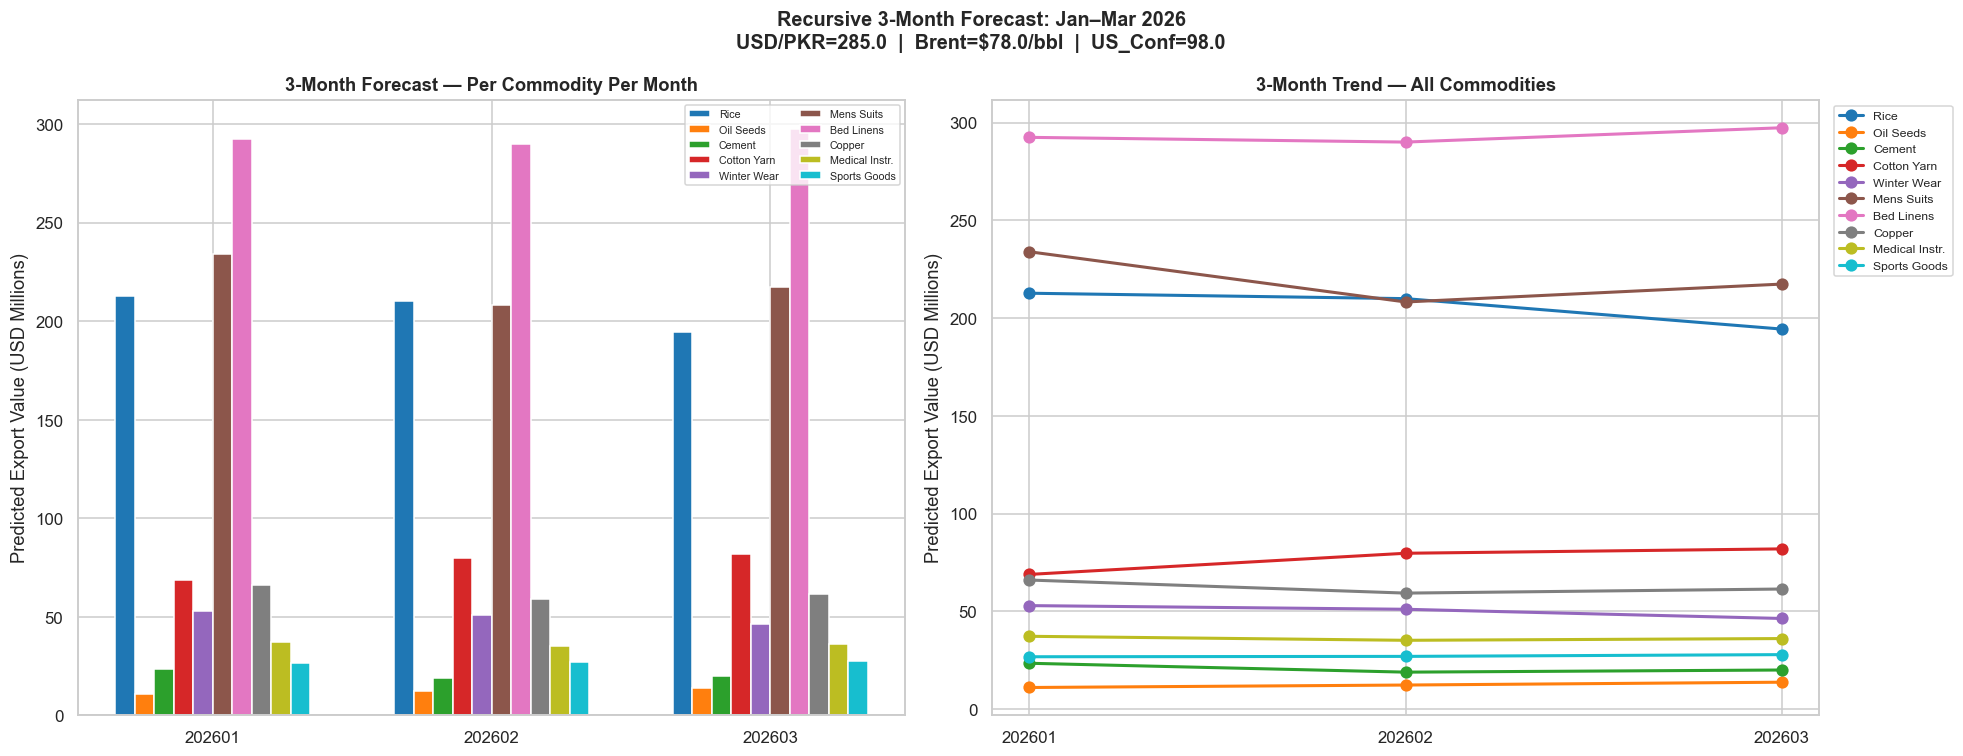

In [11]:
COLORS = list(plt.cm.tab10.colors)
month_labels = [str(m) for m in sorted(multi_df['Month'].unique())]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Chart 1: Grouped bar chart — each commodity across 3 months ---
x       = np.arange(len(month_labels))
n_comms = len(hs_categories)
width   = 0.07

for i, hs in enumerate(sorted(hs_categories)):
    comm_name = HS_LABELS[hs]
    vals = [
        multi_df[(multi_df['HS_Code'] == hs) & (multi_df['Month'] == int(m))]['Predicted_M'].values[0]
        for m in month_labels
    ]
    offset = (i - n_comms / 2) * width + width / 2
    axes[0].bar(x + offset, vals, width=width, label=comm_name, color=COLORS[i], edgecolor='white')

axes[0].set_xticks(x)
axes[0].set_xticklabels(month_labels)
axes[0].set_ylabel('Predicted Export Value (USD Millions)')
axes[0].set_title('3-Month Forecast — Per Commodity Per Month', fontweight='bold')
axes[0].legend(fontsize=7, ncol=2)

# --- Chart 2: Line chart — total exports across 3 months per commodity ---
for i, hs in enumerate(sorted(hs_categories)):
    comm_name = HS_LABELS[hs]
    vals = [
        multi_df[(multi_df['HS_Code'] == hs) & (multi_df['Month'] == int(m))]['Predicted_M'].values[0]
        for m in month_labels
    ]
    axes[1].plot(month_labels, vals, marker='o', linewidth=2,
                 label=comm_name, color=COLORS[i], markersize=7)

axes[1].set_ylabel('Predicted Export Value (USD Millions)')
axes[1].set_title('3-Month Trend — All Commodities', fontweight='bold')
axes[1].legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle(
    f'Recursive 3-Month Forecast: Jan–Mar 2026\n'
    f'USD/PKR={USD_PKR}  |  Brent=${BRENT_OIL}/bbl  |  US_Conf={US_CONF}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
### Professional Forecast Chart — Industry Style

This chart follows the standard used in financial and trade forecasting reports:
- **Solid dark line** — last 12 months of actual historical exports
- **Dashed red line** — 3-month recursive forecast
- **Shaded confidence band** — grows wider with each step (uncertainty increases the further out you forecast)
- **Vertical separator** — divides historical from forecast zone
- Confidence band width is based on the model's test MAPE (20.41%)

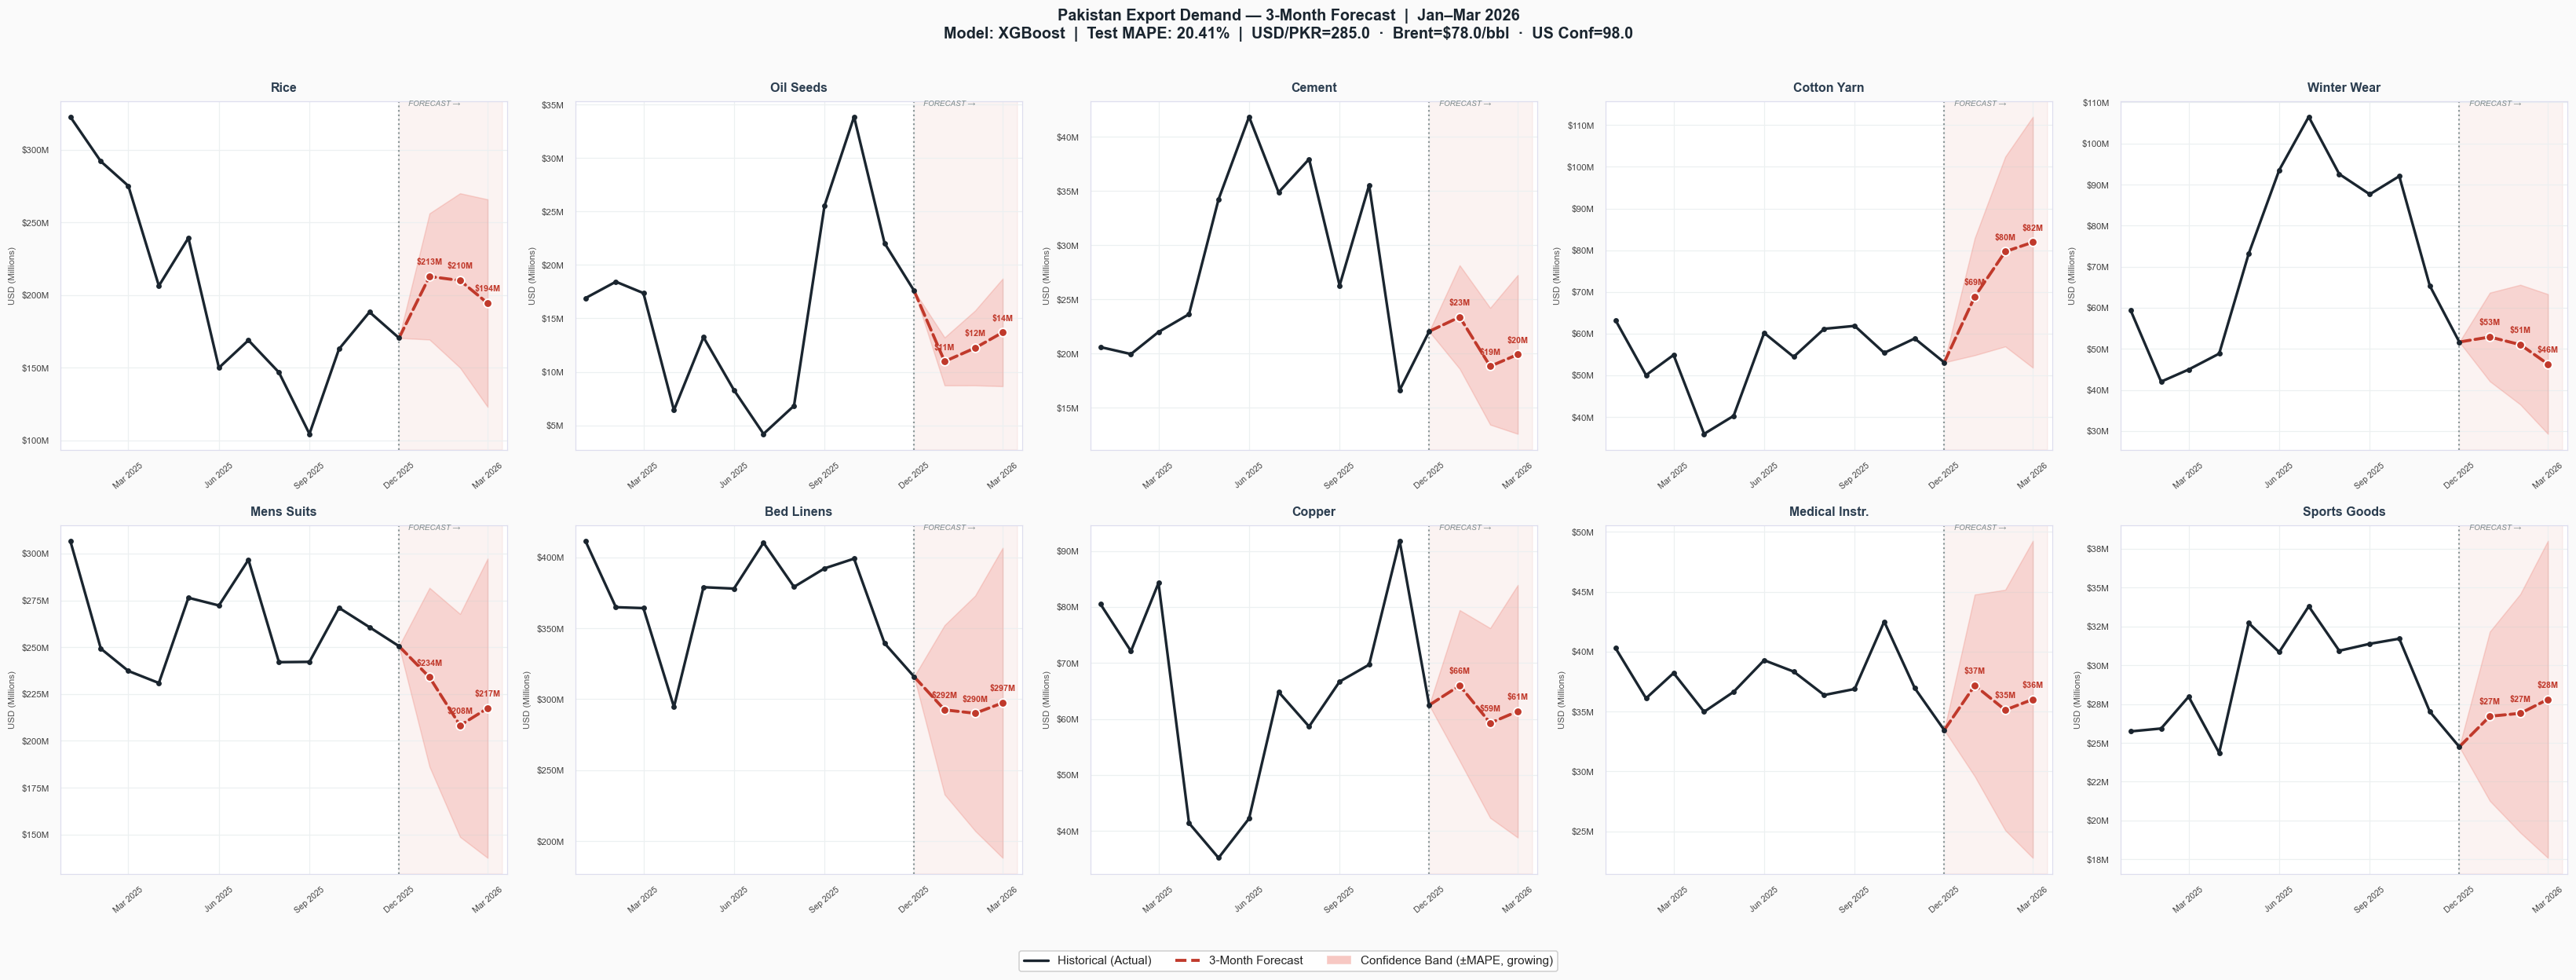

Chart saved to Models/forecast_chart_jan_mar_2026.png


In [12]:
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── Settings ────────────────────────────────────────────────────────────────
HIST_MONTHS   = 12          # how many historical months to show
BASE_UNCERT   = test_mape / 100          # model MAPE as a fraction (0.2041)
UNCERT_GROW   = [1.0, 1.4, 1.8]         # uncertainty multiplier per forecast step

HIST_COLOR    = '#1a252f'
FC_COLOR      = '#c0392b'
BAND_COLOR    = '#e74c3c'
GRID_COLOR    = '#ecf0f1'
SEP_COLOR     = '#7f8c8d'

# ── Build historical dates (last HIST_MONTHS months of master data) ──────────
last_date  = master_df['Date_YYYYMM'].max()
last_dt    = pd.to_datetime(str(last_date), format='%Y%m')
hist_keys  = [int((last_dt - pd.DateOffset(months=i)).strftime('%Y%m'))
              for i in range(HIST_MONTHS - 1, -1, -1)]
hist_dates = pd.to_datetime([str(m) for m in hist_keys], format='%Y%m')

# ── Build forecast dates ─────────────────────────────────────────────────────
fc_keys   = sorted(multi_df['Month'].unique())
fc_dates  = pd.to_datetime([str(m) for m in fc_keys], format='%Y%m')

cutoff_dt = hist_dates[-1]   # point where forecast begins

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(30, 11))
fig.patch.set_facecolor('#fafafa')
axes = axes.flatten()

for i, hs in enumerate(sorted(hs_categories)):
    ax  = axes[i]
    ax.set_facecolor('#ffffff')

    # Historical values
    hist_vals = []
    for m in hist_keys:
        sub = master_df[(master_df['HS_Code'] == hs) & (master_df['Date_YYYYMM'] == m)]
        hist_vals.append(sub['Export_Value_USD'].values[0] / 1e6 if len(sub) else np.nan)

    # Forecast values
    fc_vals = [
        multi_df[(multi_df['HS_Code'] == hs) & (multi_df['Month'] == m)]['Predicted_M'].values[0]
        for m in fc_keys
    ]

    # Confidence bands — growing uncertainty per step
    upper = [fc_vals[j] * (1 + BASE_UNCERT * UNCERT_GROW[j]) for j in range(len(fc_vals))]
    lower = [max(0, fc_vals[j] * (1 - BASE_UNCERT * UNCERT_GROW[j])) for j in range(len(fc_vals))]

    # Connect last historical point to forecast for a smooth join
    join_dates  = [cutoff_dt] + list(fc_dates)
    join_vals   = [hist_vals[-1]] + fc_vals
    join_upper  = [hist_vals[-1]] + upper
    join_lower  = [hist_vals[-1]] + lower

    # ── Shaded forecast zone ────────────────────────────────────────────────
    ax.axvspan(cutoff_dt, fc_dates[-1] + pd.DateOffset(days=15),
               alpha=0.06, color=FC_COLOR, zorder=0)

    # ── Confidence band ─────────────────────────────────────────────────────
    ax.fill_between(join_dates, join_lower, join_upper,
                    alpha=0.18, color=BAND_COLOR, zorder=1, label='Confidence band')

    # ── Historical line ──────────────────────────────────────────────────────
    ax.plot(hist_dates, hist_vals,
            color=HIST_COLOR, linewidth=2.2, zorder=3, solid_capstyle='round')
    ax.plot(hist_dates, hist_vals,
            'o', color=HIST_COLOR, markersize=3.5, zorder=4)

    # ── Forecast line ────────────────────────────────────────────────────────
    ax.plot(join_dates, join_vals,
            color=FC_COLOR, linewidth=2.5, linestyle='--', zorder=3,
            dash_capstyle='round')
    ax.plot(fc_dates, fc_vals,
            'o', color=FC_COLOR, markersize=7, zorder=5, markeredgecolor='white',
            markeredgewidth=1.2)

    # ── Vertical separator ───────────────────────────────────────────────────
    ax.axvline(cutoff_dt, color=SEP_COLOR, linewidth=1.4,
               linestyle=':', zorder=2, alpha=0.9)

    # "FORECAST" annotation just right of the separator
    ax.annotate('FORECAST →',
                xy=(cutoff_dt, ax.get_ylim()[1] if ax.get_ylim()[1] != 0 else 1),
                xytext=(8, -4), textcoords='offset points',
                fontsize=6.5, color=SEP_COLOR, fontstyle='italic', zorder=6)

    # ── Label each forecast dot with value ──────────────────────────────────
    for dt, val in zip(fc_dates, fc_vals):
        ax.annotate(f'${val:.0f}M',
                    xy=(dt, val),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=7, color=FC_COLOR, fontweight='bold', zorder=7)

    # ── Axes formatting ─────────────────────────────────────────────────────
    ax.set_title(f'{HS_LABELS[hs]}', fontsize=10.5, fontweight='bold',
                 color='#2c3e50', pad=8)
    ax.set_ylabel('USD (Millions)', fontsize=7.5, color='#555')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.tick_params(axis='x', rotation=40, labelsize=7, colors='#444')
    ax.tick_params(axis='y', labelsize=7.5, colors='#444')
    ax.set_xlim(hist_dates[0] - pd.DateOffset(days=10),
                fc_dates[-1]  + pd.DateOffset(days=20))
    ax.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
    for spine in ax.spines.values():
        spine.set_edgecolor('#dde')
        spine.set_linewidth(0.8)

# ── Global legend ────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], color=HIST_COLOR, linewidth=2.2, label='Historical (Actual)'),
    Line2D([0], [0], color=FC_COLOR,   linewidth=2.5, linestyle='--', label='3-Month Forecast'),
    mpatches.Patch(facecolor=BAND_COLOR, alpha=0.3, label=f'Confidence Band (±MAPE, growing)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           fontsize=10, frameon=True, framealpha=0.95,
           edgecolor='#ccc', bbox_to_anchor=(0.5, -0.01))

fig.suptitle(
    f'Pakistan Export Demand — 3-Month Forecast  |  Jan–Mar 2026\n'
    f'Model: XGBoost  |  Test MAPE: {test_mape}%  |  '
    f'USD/PKR={USD_PKR}  ·  Brent=${BRENT_OIL}/bbl  ·  US Conf={US_CONF}',
    fontsize=13, fontweight='bold', color='#1a252f', y=1.01
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('../Models/forecast_chart_jan_mar_2026.png',
            dpi=150, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print('Chart saved to Models/forecast_chart_jan_mar_2026.png')

---
## Section 8 — Scenario Simulator

Hold all other variables constant and vary the **USD/PKR exchange rate** across a range.  
This shows how sensitive Pakistan's export forecasts are to currency depreciation.

The same pattern works for Brent Oil or US Consumer Confidence — just swap the variable.

In [13]:
# Vary USD/PKR from 250 to 330 — hold everything else fixed
TARGET_MONTH = 202601
BRENT_OIL    = 78.0
US_CONF      = 98.0

pkr_range = np.arange(250, 335, 10)

# Collect predictions for all commodities across all PKR scenarios
scenario_data = {}
for hs in hs_categories:
    preds = [make_prediction(hs, TARGET_MONTH, pkr, BRENT_OIL, US_CONF) / 1e6
             for pkr in pkr_range]
    scenario_data[HS_LABELS[hs]] = preds

scenario_df = pd.DataFrame(scenario_data, index=pkr_range)

print('Scenario: USD/PKR impact on Jan 2026 predicted exports (USD Millions)')
print(f'Fixed: Brent=${BRENT_OIL}, US_Conf={US_CONF}')
print('=' * 65)
print(scenario_df.round(1).to_string())

Scenario: USD/PKR impact on Jan 2026 predicted exports (USD Millions)
Fixed: Brent=$78.0, US_Conf=98.0
           Rice  Oil Seeds     Cement  Cotton Yarn  Winter Wear  Mens Suits  Bed Linens     Copper  Medical Instr.  Sports Goods
250  206.800003       11.6  22.799999    66.800003    50.299999  234.699997  301.600006  65.800003       36.799999     26.900000
260  206.800003       11.6  22.799999    66.800003    50.299999  237.399994  301.299988  65.800003       36.700001     26.900000
270  203.199997       11.6  23.400000    67.800003    51.400002  238.199997  302.100006  66.699997       37.700001     27.200001
280  203.199997       11.6  23.400000    67.800003    51.400002  238.199997  302.100006  66.699997       37.700001     27.200001
290  213.399994       22.6  26.600000    76.800003    56.599998  235.000000  299.200012  70.800003       38.799999     30.700001
300  213.399994       22.6  26.600000    76.800003    56.599998  235.000000  299.200012  70.800003       38.799999     30.7

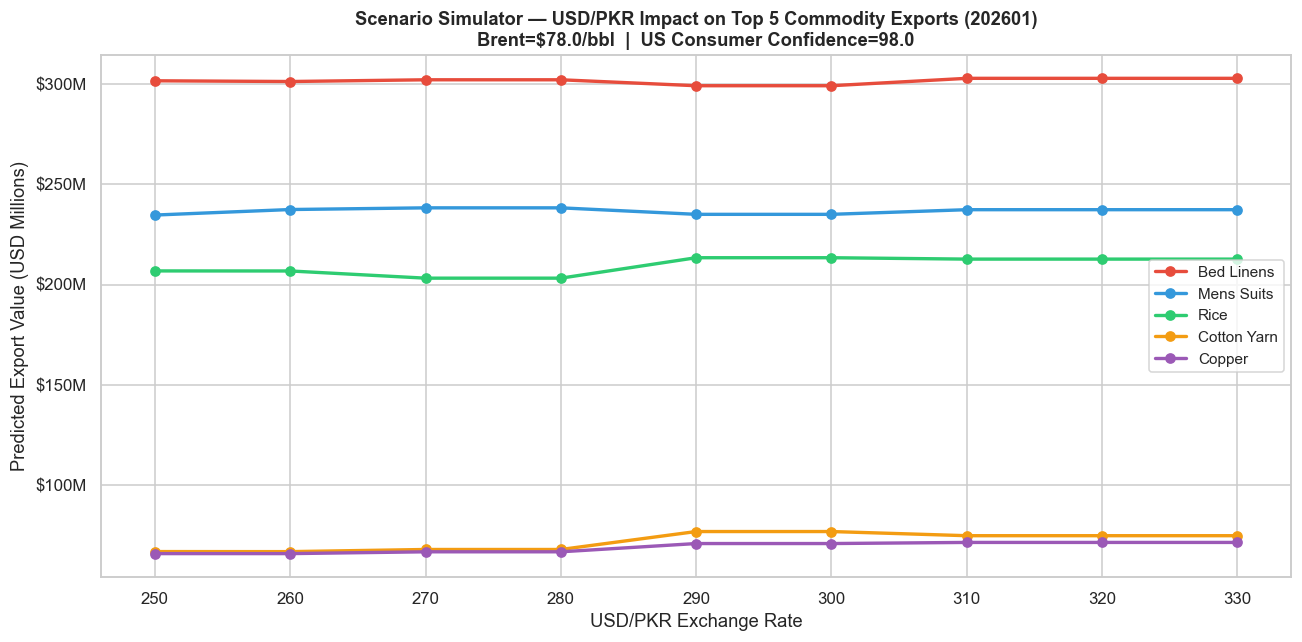

In [14]:
# Plot USD/PKR scenario for the top 5 commodities by predicted export value
top5 = forecast_df.head(5)['Commodity'].tolist()

fig, ax = plt.subplots(figsize=(12, 6))
colors_line = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for i, comm in enumerate(top5):
    ax.plot(pkr_range, scenario_df[comm],
            marker='o', linewidth=2.2, label=comm,
            color=colors_line[i], markersize=6)

ax.set_xlabel('USD/PKR Exchange Rate')
ax.set_ylabel('Predicted Export Value (USD Millions)')
ax.set_title(
    f'Scenario Simulator — USD/PKR Impact on Top 5 Commodity Exports ({TARGET_MONTH})\n'
    f'Brent=${BRENT_OIL}/bbl  |  US Consumer Confidence={US_CONF}',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fM'))
plt.tight_layout()
plt.show()

---
## Summary

### What Was Accomplished
- Loaded `xgboost_champion.pkl` — no retraining required
- Built `make_prediction()` — one commodity, one month, 3 macro inputs → USD forecast
- Built `forecast_n_months()` — recursive multi-step forecasting for all 10 commodities
- Generated a 3-month forecast (Jan–Mar 2026) with chained lag propagation
- Ran a scenario simulation showing how USD/PKR changes affect export predictions

### Key Design Decisions
- **Recursive forecasting**: Month 1 prediction becomes Lag_1M for Month 2, and so on
- **Forecast buffer**: Cleanly separates actual historical data from predicted values
- **Lag values are auto-looked-up** — user only supplies macro inputs
- **Category dtype applied at inference** — same as training, prevents silent encoding errors
- **Predictions clamped to >= 0** — model can occasionally predict small negatives near zero

### Mapping to FastAPI Backend
| Notebook 4 | FastAPI Equivalent |
|---|---|
| `joblib.load(artifact)` | App startup — load model once into memory |
| `make_prediction(...)` | `POST /predict` endpoint |
| All-commodity loop | `GET /forecast?month=202601` endpoint |
| `forecast_n_months(...)` | `GET /forecast?start=202601&months=3` endpoint |
| Scenario simulator | `POST /scenario` endpoint |

### Next Step → FastAPI Backend
Wrap `make_prediction()` and `forecast_n_months()` in FastAPI routes and serve predictions over HTTP.